# Lighting robustness evaluation

Evaluate all four YOLOv8s trolley models on a shared left-camera holdout set under clean, bright, dark, shadow, and evening conditions. Images used to train either model family are excluded. This notebook does not train models.

In [26]:
from pathlib import Path
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

SEED = 42
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

DATASETS_ROOT = Path(
    r"C:\Users\johan\OneDrive - mci4me.at\Master Thesis"
    r"\Source code\YOLO Datasets\dataset"
)

# Every model is evaluated on this exact same left-camera validation split.
SOURCE_ROOT = DATASETS_ROOT / "trolleys_left_only"
VAL_IMAGES = SOURCE_ROOT / "images" / "val"
VAL_LABELS = SOURCE_ROOT / "labels" / "val"
FULL_TRAIN_IMAGES = DATASETS_ROOT / "trolleys" / "images" / "train"

OUTPUT_ROOT = DATASETS_ROOT / "lighting_robustness_tests_shared_holdout"
RESULTS_ROOT = DATASETS_ROOT / "lighting_robustness_results_shared_holdout"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

device = 0 if torch.cuda.is_available() else "cpu"
batch = 0.70 if torch.cuda.is_available() else 8

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Evaluation source: {VAL_IMAGES}")

Device: CPU
Evaluation source: C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\trolleys_left_only\images\val


In [27]:
if not VAL_IMAGES.is_dir() or not VAL_LABELS.is_dir():
    raise FileNotFoundError("The left-only trolley validation split is missing.")
if not FULL_TRAIN_IMAGES.is_dir():
    raise FileNotFoundError("The full trolley training split is missing.")

left_val_images = sorted(
    path for path in VAL_IMAGES.iterdir()
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
full_train_names = {
    path.name.lower()
    for path in FULL_TRAIN_IMAGES.iterdir()
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
}

excluded_images = [
    image for image in left_val_images
    if image.name.lower() in full_train_names
]
source_images = [
    image for image in left_val_images
    if image.name.lower() not in full_train_names
]
source_labels = sorted(VAL_LABELS.glob("*.txt"))

missing_labels = [
    image.name for image in source_images
    if not (VAL_LABELS / f"{image.stem}.txt").is_file()
]

if missing_labels:
    raise RuntimeError(
        f"Evaluation split is inconsistent: {len(missing_labels)} missing labels."
    )

if not source_images:
    raise RuntimeError("No validation images found.")

if not excluded_images:
    raise RuntimeError("No overlapping full-training images were found to exclude.")

print(f"Left-only validation images: {len(left_val_images)}")
print(f"Excluded because used in full-model training: {len(excluded_images)}")
print(f"Shared held-out evaluation images: {len(source_images)}")

Left-only validation images: 59
Excluded because used in full-model training: 22
Shared held-out evaluation images: 37


In [28]:
def clean_image(image, rng):
    return image.copy()


def change_value(image, factor):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)


def bright_window(image, rng):
    return change_value(image, 1.60)


def dark_corridor(image, rng):
    return change_value(image, 0.45)


def shadow(image, rng):
    height, width = image.shape[:2]
    vertical = bool(rng.integers(0, 2))
    result = image.astype(np.float32)

    if vertical:
        boundary = int(rng.integers(max(1, width // 4), max(2, 3 * width // 4)))
        if bool(rng.integers(0, 2)):
            result[:, :boundary] *= 0.45
        else:
            result[:, boundary:] *= 0.45
    else:
        boundary = int(rng.integers(max(1, height // 4), max(2, 3 * height // 4)))
        if bool(rng.integers(0, 2)):
            result[:boundary, :] *= 0.45
        else:
            result[boundary:, :] *= 0.45

    return np.clip(result, 0, 255).astype(np.uint8)


def evening_light(image, rng):
    result = image.astype(np.float32)
    result[:, :, 2] *= 1.15  # warmer red channel
    result[:, :, 1] *= 0.95
    result[:, :, 0] *= 0.75
    result *= 0.75
    return np.clip(result, 0, 255).astype(np.uint8)


CONDITIONS = {
    "Clean": clean_image,
    "Bright Windows": bright_window,
    "Dark Corridors": dark_corridor,
    "Shadows": shadow,
    "Evening": evening_light,
}

In [29]:
def create_condition_dataset(condition_name, transform):
    slug = condition_name.lower().replace(" ", "_")
    dataset_dir = OUTPUT_ROOT / slug
    images_dir = dataset_dir / "images" / "val"
    labels_dir = dataset_dir / "labels" / "val"
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(SEED)

    for image_path in source_images:
        image = cv2.imread(str(image_path))
        if image is None:
            raise RuntimeError(f"Could not read image: {image_path}")

        transformed = transform(image, rng)
        destination = images_dir / image_path.name
        if not cv2.imwrite(str(destination), transformed):
            raise RuntimeError(f"Could not write image: {destination}")

        label_source = VAL_LABELS / f"{image_path.stem}.txt"
        label_destination = labels_dir / label_source.name
        shutil.copy2(label_source, label_destination)

    yaml_content = f'''path: "{dataset_dir.as_posix()}"
train: images/val
val: images/val

nc: 3

names:
  0: trash_trolley
  1: laundry_trolley
  2: empty_trolley
'''
    yaml_path = dataset_dir / "data.yaml"
    yaml_path.write_text(yaml_content, encoding="utf-8")

    generated_images = [
        path for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    generated_labels = list(labels_dir.glob("*.txt"))
    if len(generated_images) != len(source_images) or len(generated_labels) != len(source_images):
        raise RuntimeError(f"Incomplete generated dataset: {condition_name}")

    return dataset_dir


condition_datasets = {}
for condition_name, transform in CONDITIONS.items():
    print(f"Creating {condition_name}...")
    condition_datasets[condition_name] = create_condition_dataset(
        condition_name, transform
    )

print(f"Created {len(condition_datasets)} evaluation datasets.")

Creating Clean...
Creating Bright Windows...
Creating Dark Corridors...
Creating Shadows...
Creating Evening...
Created 5 evaluation datasets.


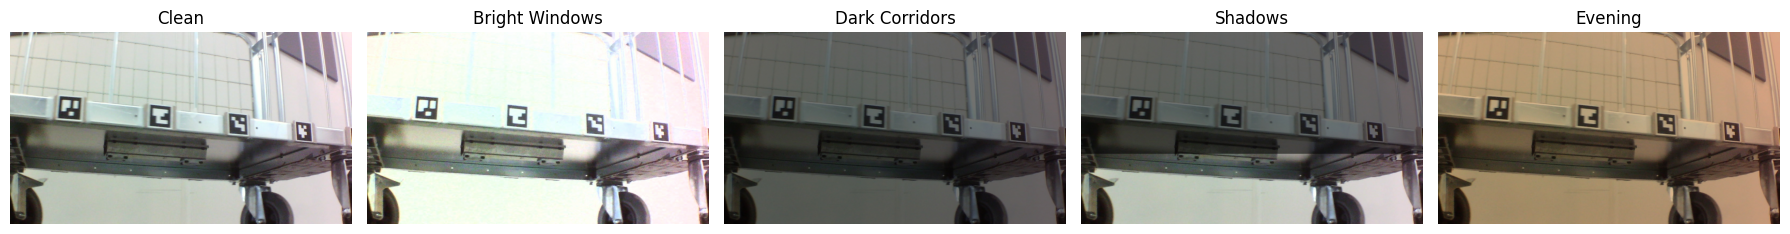

In [30]:
preview_name = source_images[0].name
fig, axes = plt.subplots(1, len(condition_datasets), figsize=(18, 4))

for axis, (condition_name, dataset_dir) in zip(axes, condition_datasets.items()):
    image = cv2.imread(str(dataset_dir / "images" / "val" / preview_name))
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(condition_name)
    axis.axis("off")

plt.tight_layout()
plt.show()

In [31]:
MODELS = {
    "Left / No augmentation": (
        DATASETS_ROOT / "trolleys_left_only" / "runs"
        / "yolov8s_no_augmentation" / "weights" / "best.pt"
    ),
    "Left / Brightness": (
        DATASETS_ROOT / "trolleys_left_only" / "runs"
        / "yolov8s_brightness_augmentation" / "weights" / "best.pt"
    ),
    "Full / No augmentation": (
        DATASETS_ROOT / "trolleys" / "runs"
        / "yolov8s_full_no_augmentation" / "weights" / "best.pt"
    ),
    "Full / Brightness": (
        DATASETS_ROOT / "trolleys" / "runs"
        / "yolov8s_full_brightness_augmentation" / "weights" / "best.pt"
    ),
}

for model_name, checkpoint in MODELS.items():
    if not checkpoint.is_file():
        raise FileNotFoundError(f"Missing checkpoint for {model_name}: {checkpoint}")
    print(f"{model_name:<25} {checkpoint}")

Left / No augmentation    C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\trolleys_left_only\runs\yolov8s_no_augmentation\weights\best.pt
Left / Brightness         C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\trolleys_left_only\runs\yolov8s_brightness_augmentation\weights\best.pt
Full / No augmentation    C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\trolleys\runs\yolov8s_full_no_augmentation\weights\best.pt
Full / Brightness         C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\trolleys\runs\yolov8s_full_brightness_augmentation\weights\best.pt


In [32]:
rows = []

for model_name, checkpoint in MODELS.items():
    print(f"\nLoading {model_name}")
    model = YOLO(str(checkpoint))

    for condition_name, dataset_dir in condition_datasets.items():
        print(f"  Evaluating {condition_name}...")
        run_name = (
            model_name.lower().replace(" / ", "_").replace(" ", "_")
            + "__"
            + condition_name.lower().replace(" ", "_")
        )

        metrics = model.val(
            data=str(dataset_dir / "data.yaml"),
            split="val",
            imgsz=640,
            batch=batch,
            device=device,
            workers=0,
            plots=True,
            verbose=False,
            project=str(RESULTS_ROOT / "validation_runs"),
            name=run_name,
            exist_ok=True,
        )

        class_ap50 = metrics.box.ap50
        class_ap = metrics.box.ap
        rows.append({
            "Model": model_name,
            "Condition": condition_name,
            "Precision": float(metrics.box.mp),
            "Recall": float(metrics.box.mr),
            "mAP50": float(metrics.box.map50),
            "mAP50-95": float(metrics.box.map),
            "Trash AP50": float(class_ap50[0]),
            "Laundry AP50": float(class_ap50[1]),
            "Empty AP50": float(class_ap50[2]),
            "Trash AP50-95": float(class_ap[0]),
            "Laundry AP50-95": float(class_ap[1]),
            "Empty AP50-95": float(class_ap[2]),
        })

results_df = pd.DataFrame(rows)
results_df.to_csv(RESULTS_ROOT / "lighting_robustness_detailed.csv", index=False)

display(
    results_df.style.format({
        column: "{:.4f}"
        for column in results_df.columns
        if column not in {"Model", "Condition"}
    })
)

print(f"\nSaved: {RESULTS_ROOT / 'lighting_robustness_detailed.csv'}")


Loading Left / No augmentation
  Evaluating Clean...
Ultralytics 8.4.14  Python-3.11.9 torch-2.10.0+cpu CPU (AMD Ryzen 9 7900X 12-Core Processor)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1820.4365.1 MB/s, size: 224.3 KB)
val: Scanning C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\lighting_robustness_tests_shared_holdout\clean\labels\val.cache... 37 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 37/37  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.3it/s 2.2s0.6s
                   all         37         37      0.992          1      0.995      0.953
Speed: 0.4ms preprocess, 48.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\lighting_robustness_results_shared_holdout\validation_r

,Model,Condition,Precision,Recall,mAP50,mAP50-95,Trash AP50,Laundry AP50,Empty AP50,Trash AP50-95,Laundry AP50-95,Empty AP50-95
0,Left / No augmentation,Clean,0.9920,1.0000,0.9950,0.9530,0.9950,0.9950,0.9950,0.9237,0.9402,0.9950
1,Left / No augmentation,Bright Windows,0.9666,0.9815,0.9950,0.9573,0.9950,0.9950,0.9950,0.9151,0.9721,0.9848
2,Left / No augmentation,Dark Corridors,0.9896,1.0000,0.9950,0.9237,0.9950,0.9950,0.9950,0.9483,0.9332,0.8897
3,Left / No augmentation,Shadows,0.9935,1.0000,0.9950,0.9484,0.9950,0.9950,0.9950,0.9177,0.9442,0.9834
4,Left / No augmentation,Evening,0.9897,1.0000,0.9950,0.9302,0.9950,0.9950,0.9950,0.8635,0.9322,0.9950
5,Left / Brightness,Clean,0.9803,0.9748,0.9950,0.9311,0.9950,0.9950,0.9950,0.9107,0.9616,0.9211
6,Left / Brightness,Bright Windows,0.9665,0.9738,0.9950,0.9231,0.9950,0.9950,0.9950,0.9161,0.9443,0.9088
7,Left / Brightness,Dark Corridors,0.8858,0.9611,0.9891,0.9051,0.9834,0.9888,0.9950,0.8893,0.9263,0.8998
8,Left / Brightness,Shadows,0.9524,0.9455,0.9929,0.9220,0.9950,0.9888,0.9950,0.9028,0.9458,0.9174
9,Left / Brightness,Evening,0.9677,0.9821,0.9930,0.9232,0.9889,0.9950,0.9950,0.9094,0.9477,0.9124



Saved: C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\lighting_robustness_results_shared_holdout\lighting_robustness_detailed.csv


In [33]:
map_table = results_df.pivot(index="Model", columns="Condition", values="mAP50-95")
map_table = map_table.reindex(index=MODELS.keys(), columns=CONDITIONS.keys())

clean_scores = results_df[
    results_df["Condition"] == "Clean"
][["Model", "mAP50-95"]].rename(columns={"mAP50-95": "Clean mAP50-95"})

robustness_summary = (
    results_df[results_df["Condition"] != "Clean"]
    .groupby("Model", as_index=False)
    .agg(
        **{
            "Mean altered mAP50-95": ("mAP50-95", "mean"),
            "Worst altered mAP50-95": ("mAP50-95", "min"),
        }
    )
    .merge(clean_scores, on="Model")
)
robustness_summary["Mean retained performance"] = (
    robustness_summary["Mean altered mAP50-95"]
    / robustness_summary["Clean mAP50-95"].replace(0, np.nan)
)
robustness_summary = robustness_summary.sort_values(
    "Mean altered mAP50-95", ascending=False
).reset_index(drop=True)

map_table.to_csv(RESULTS_ROOT / "lighting_map50_95_matrix.csv")
robustness_summary.to_csv(RESULTS_ROOT / "lighting_robustness_summary.csv", index=False)

print("mAP50-95 by model and condition")
display(map_table.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen"))

print("Overall robustness summary")
display(
    robustness_summary.style.format({
        "Mean altered mAP50-95": "{:.4f}",
        "Worst altered mAP50-95": "{:.4f}",
        "Clean mAP50-95": "{:.4f}",
        "Mean retained performance": "{:.1%}",
    }).highlight_max(
        subset=["Mean altered mAP50-95", "Worst altered mAP50-95", "Mean retained performance"],
        color="lightgreen",
    )
)

mAP50-95 by model and condition


Condition,Clean,Bright Windows,Dark Corridors,Shadows,Evening
Model,,,,,
Left / No augmentation,0.9530,0.9573,0.9237,0.9484,0.9302
Left / Brightness,0.9311,0.9231,0.9051,0.9220,0.9232
Full / No augmentation,0.9856,0.8485,0.8522,0.9201,0.4157
Full / Brightness,0.9609,0.9032,0.9420,0.9683,0.5719


Overall robustness summary


,Model,Mean altered mAP50-95,Worst altered mAP50-95,Clean mAP50-95,Mean retained performance
0,Left / No augmentation,0.9399,0.9237,0.9530,98.6%
1,Left / Brightness,0.9183,0.9051,0.9311,98.6%
2,Full / Brightness,0.8463,0.5719,0.9609,88.1%
3,Full / No augmentation,0.7592,0.4157,0.9856,77.0%


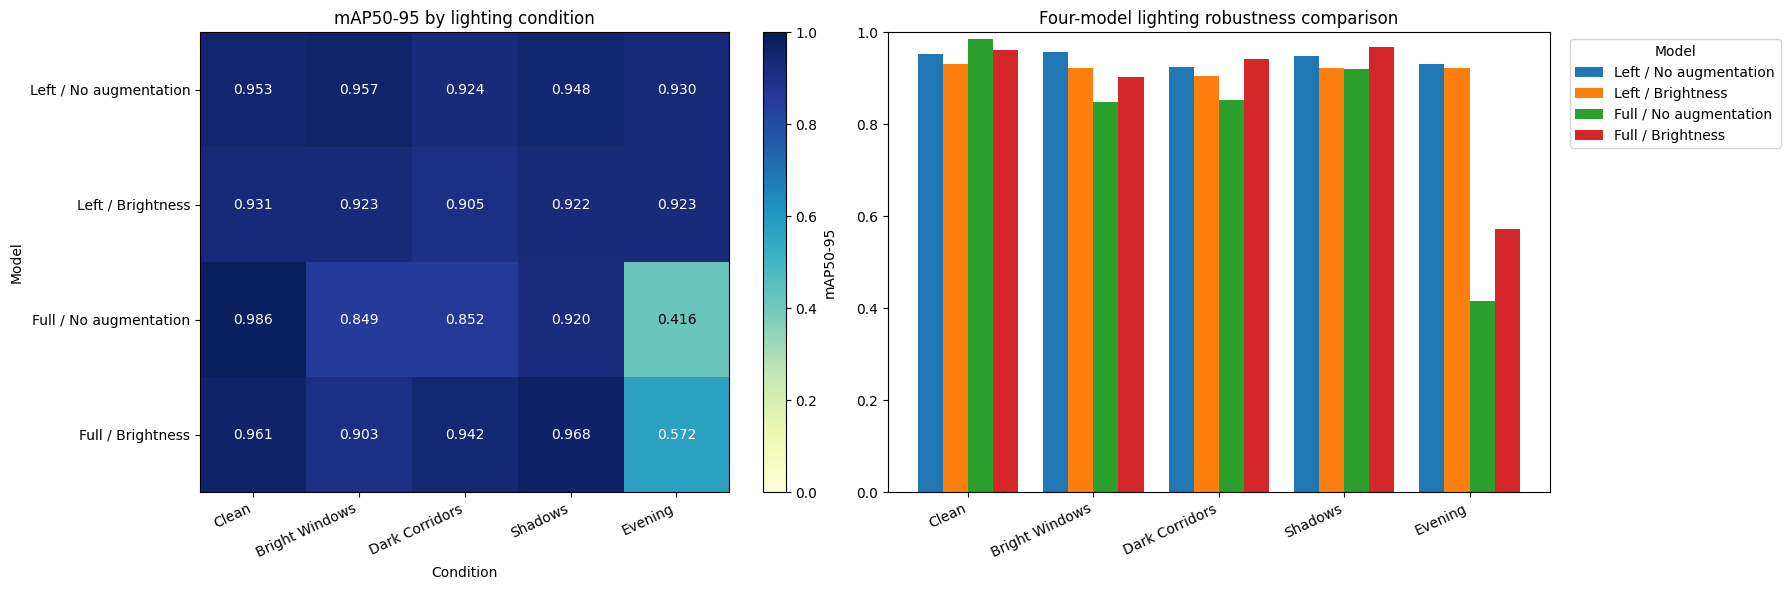

Saved: C:\Users\johan\OneDrive - mci4me.at\Master Thesis\Source code\YOLO Datasets\dataset\lighting_robustness_results_shared_holdout\lighting_robustness_comparison.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

heatmap = axes[0].imshow(
    map_table.to_numpy(), cmap="YlGnBu", vmin=0, vmax=1, aspect="auto"
)
axes[0].set_xticks(range(len(map_table.columns)), map_table.columns, rotation=25, ha="right")
axes[0].set_yticks(range(len(map_table.index)), map_table.index)
for row in range(len(map_table.index)):
    for column in range(len(map_table.columns)):
        value = map_table.iloc[row, column]
        axes[0].text(
            column, row, f"{value:.3f}", ha="center", va="center",
            color="white" if value > 0.55 else "black",
        )
fig.colorbar(heatmap, ax=axes[0], label="mAP50-95")
axes[0].set_title("mAP50-95 by lighting condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Model")

condition_names = list(CONDITIONS.keys())
model_names = list(MODELS.keys())
x = np.arange(len(condition_names))
bar_width = 0.8 / len(model_names)

for model_index, model_name in enumerate(model_names):
    model_scores = (
        results_df[results_df["Model"] == model_name]
        .set_index("Condition")
        .reindex(condition_names)["mAP50-95"]
        .to_numpy()
    )
    offset = (model_index - (len(model_names) - 1) / 2) * bar_width
    axes[1].bar(x + offset, model_scores, width=bar_width, label=model_name)

axes[1].set_xticks(x, condition_names, rotation=25, ha="right")
axes[1].set_title("Four-model lighting robustness comparison")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
figure_path = RESULTS_ROOT / "lighting_robustness_comparison.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")